<a href="https://colab.research.google.com/github/Buvanav/pepper_project-/blob/collab/pepper_last.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
import os

# Mount your Google Drive
drive.mount('/content/drive')

# Path to your dataset in Google Drive
dataset_path = '/content/drive/MyDrive/pepper dataset '  # <-- change if your folder name is different

# Check folders
print("Classes in dataset:", os.listdir(dataset_path))


Mounted at /content/drive
Classes in dataset: ['unhealthy', 'healthy']


In [ ]:
import shutil
import random

# Base directory for split data
base_dir = '/content/pepper_data'
os.makedirs(base_dir, exist_ok=True)

# Create folders
for split in ['train', 'val', 'test']:
    for cls in ['healthy', 'unhealthy']:
        os.makedirs(os.path.join(base_dir, split, cls), exist_ok=True)

# Function to split dataset
def split_data(source_dir, train_dir, val_dir, test_dir, split_ratio=(0.7,0.15,0.15)):
    classes = os.listdir(source_dir)
    for cls in classes:
        images = os.listdir(os.path.join(source_dir, cls))
        random.shuffle(images)
        total = len(images)
        train_end = int(split_ratio[0]*total)
        val_end = int((split_ratio[0]+split_ratio[1])*total)

        for i, img in enumerate(images):
            src_path = os.path.join(source_dir, cls, img)
            if i < train_end:
                dst_path = os.path.join(train_dir, cls, img)
            elif i < val_end:
                dst_path = os.path.join(val_dir, cls, img)
            else:
                dst_path = os.path.join(test_dir, cls, img)
            shutil.copy(src_path, dst_path)

# Run split
split_data(dataset_path,
           os.path.join(base_dir,'train'),
           os.path.join(base_dir,'val'),
           os.path.join(base_dir,'test'))

print("Dataset split done!")


Dataset split done!


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# Training with augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

# Validation and test: only rescale
val_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    os.path.join(base_dir,'train'),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

val_gen = val_datagen.flow_from_directory(
    os.path.join(base_dir,'val'),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

test_gen = test_datagen.flow_from_directory(
    os.path.join(base_dir,'test'),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)


Found 781 images belonging to 2 classes.
Found 168 images belonging to 2 classes.
Found 168 images belonging to 2 classes.


In [ ]:
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model

# Load MobileNetV2
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224,224,3))
base_model.trainable = False  # freeze base

# Add custom layers
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
output = Dense(1, activation='sigmoid')(x)  # binary classification

model = Model(inputs=base_model.input, outputs=output)


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,422,081 (9.24 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
from sklearn.utils import class_weight
import numpy as np

# Compute class weights
y_train = train_gen.classes
class_weights = class_weight.compute_class_weight(
    'balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weights = dict(enumerate(class_weights))
print("Class weights:", class_weights)


Class weights: {0: np.float64(4.648809523809524), 1: np.float64(0.56025824964132)}


In [ ]:
EPOCHS = 10

history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS,
    class_weight=class_weights
)


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 59s 2s/step - accuracy: 0.7716 - loss: 0.4344 - val_accuracy: 0.8512 - val_loss: 0.3239
Epoch 2/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 62s 2s/step - accuracy: 0.9349 - loss: 0.1508 - val_accuracy: 0.7917 - val_loss: 0.6022
Epoch 3/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 51s 2s/step - accuracy: 0.9195 - loss: 0.1320 - val_accuracy: 0.9643 - val_loss: 0.0698
Epoch 4/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 83s 2s/step - accuracy: 0.9757 - loss: 0.0670 - val_accuracy: 0.9524 - val_loss: 0.0775
Epoch 5/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 49s 2s/step - accuracy: 0.9822 - loss: 0.0518 - val_accuracy: 0.9524 - val_loss: 0.0848
Epoch 6/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 48s 2s/step - accuracy: 0.9900 - loss: 0.0298 - val_accuracy: 0.9524 - val_loss: 0.0926
Epoch 7/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 52s 2s/step - accuracy: 0.9747 - loss: 0.0614 - val_accuracy: 0.9286 - val_loss: 0.1596
Epoch 8/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 48s 2s/step - accuracy: 0.9906 - loss: 0.0464 - val_accuracy: 0.9702 - val_loss:

Error: The 'history' variable is not defined.
Please ensure you have run the model training cell (the cell defining 'history = model.fit(...)') before running this plotting cell.


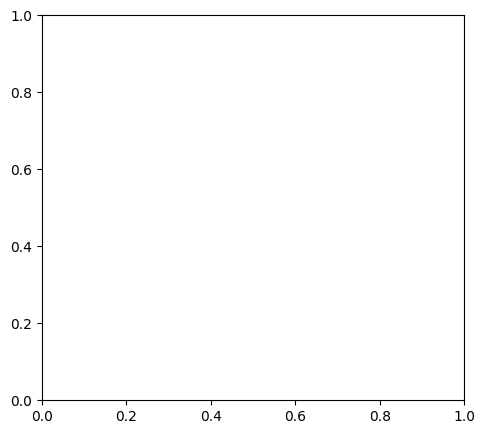

In [ ]:
# Step 7: Plot Accuracy & Loss
# ========================
import matplotlib.pyplot as plt # Ensure matplotlib is imported for plotting

try:
    plt.figure(figsize=(12,5))

    # Accuracy plot
    plt.subplot(1,2,1)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title('Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    # Loss plot
    plt.subplot(1,2,2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    plt.show()
except NameError:
    print("Error: The 'history' variable is not defined.")
    print("Please ensure you have run the model training cell (the cell defining 'history = model.fit(...)') before running this plotting cell.")
except Exception as e:
    print(f"An unexpected error occurred: {e}")


In [ ]:
test_loss, test_acc = model.evaluate(test_gen)
print("Test Accuracy: {:.2f}%".format(test_acc*100))


NameError: name 'test_gen' is not defined

In [ ]:
model.save('/content/drive/MyDrive/pepper_mobilenet_model.h5')
print("Model saved to Drive!")


Model saved to Drive!


In [ ]:
# Unfreeze some layers for fine-tuning
base_model.trainable = True
for layer in base_model.layers[:100]:
    layer.trainable = False

model.compile(optimizer=tf.keras.optimizers.Adam(1e-5),
              loss='binary_crossentropy',
              metrics=['accuracy'])

history_ft = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=5,
    class_weight=class_weights
)


Epoch 1/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 90s 3s/step - accuracy: 0.9570 - loss: 0.7092 - val_accuracy: 0.9345 - val_loss: 0.1751
Epoch 2/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 69s 3s/step - accuracy: 0.9642 - loss: 0.2752 - val_accuracy: 0.9286 - val_loss: 0.2164
Epoch 3/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 83s 3s/step - accuracy: 0.9879 - loss: 0.0429 - val_accuracy: 0.9226 - val_loss: 0.2205
Epoch 4/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 70s 3s/step - accuracy: 0.9816 - loss: 0.0607 - val_accuracy: 0.9226 - val_loss: 0.2279
Epoch 5/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 71s 3s/step - accuracy: 0.9884 - loss: 0.0316 - val_accuracy: 0.9286 - val_loss: 0.2042


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Auto-extract from previous training (history persists in Colab)
try:
    peak_train_acc = max(history.history['accuracy']) * 100
    peak_val_acc = max(history.history['val_accuracy']) * 100
    print(f"Peak Train Accuracy: {peak_train_acc:.2f}%")
    print(f"Peak Val Accuracy: {peak_val_acc:.2f}%")

    # Replot to match your image
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train Acc', color='orange')
    plt.plot(history.history['val_accuracy'], label='Val Acc', color='blue')
    plt.title('Accuracy')
    plt.ylabel('Accuracy')
    plt.xlabel('Epoch')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train Loss', color='orange')
    plt.plot(history.history['val_loss'], label='Val Loss', color='blue')
    plt.title('Loss')
    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend()

    plt.tight_layout()
    plt.show()

except NameError:
    print("Run training cell first! Look for: history = model.fit(...)")




Run training cell first! Look for: history = model.fit(...)


In [ ]:
from tensorflow.keras.models import load_model
model = load_model('/content/drive/MyDrive/pepper_mobilenet_model.h5')


In [ ]:
!ls /content/drive/MyDrive


 17576682255943015874329618287176.jpg
'aadhar buvana (1)_copy.pdf'
'aadhar buvana (1).pdf'
'AI-powered Deepfake Voice Attack Detection in Encrypted VoIP.pdf'
'Colab Notebooks'
 commuity.jpg
'CYBER REPORT TECHNO REALM (1).pdf'
'CYBER REPORT TECHNO REALM.pdf'
'Global warming and causes (1).docx'
'Global warming and causes (1).gdoc'
'Global warming and causes (1).pdf'
'Global warming and causes (2).docx'
'Global warming and causes.docx'
'Global warming and causes.gdoc'
'Global warming and causes.pdf'
'Global warming effects and causes  (1).docx'
'Global warming effects and causes .docx'
'Global warming effects and causes .gdoc'
'id card_1.pdf'
 ID_CARD.pdf
'IMG_20231121_165737 (1).jpg'
 IMG_20231121_165737.jpg
 IMG-20250912-WA0006.jpg
 paid
'pepper dataset '
 pepper_dataset
 pepper_leaf_disease_model.h5
 pepper_leaf_disease_model.keras
 pepper_mobilenet_model.h5
'Untitled document (1).docx'
'Untitled document.docx'
'Untitled document.gdoc'


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


6/6 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step
Classification Report:
              precision    recall  f1-score   support

     Healthy       0.12      1.00      0.22        18
   Unhealthy       1.00      0.13      0.22       150

    accuracy                           0.22       168
   macro avg       0.56      0.56      0.22       168
weighted avg       0.91      0.22      0.22       168



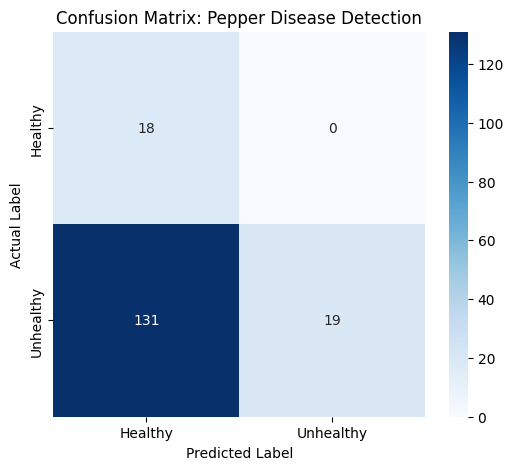

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# 1. Get predictions
test_gen.reset()
predictions = model.predict(test_gen)
# Since it's Sigmoid (binary), we convert probabilities > 0.5 to 1, else 0
y_pred = (predictions > 0.5).astype(int).flatten()
y_true = test_gen.classes

# 2. Generate Classification Report
print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=['Healthy', 'Unhealthy']))

# 3. Create Confusion Matrix Plot
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Healthy', 'Unhealthy'],
            yticklabels=['Healthy', 'Unhealthy'])
plt.title('Confusion Matrix: Pepper Disease Detection')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

In [ ]:
# Try flipping the logic to see if the indices were swapped
y_pred_flipped = (predictions < 0.5).astype(int).flatten()

print("Revised Classification Report:")
print(classification_report(y_true, y_pred_flipped, target_names=['Healthy', 'Unhealthy']))

Revised Classification Report:
              precision    recall  f1-score   support

     Healthy       0.00      0.00      0.00        18
   Unhealthy       0.88      0.87      0.88       150

    accuracy                           0.78       168
   macro avg       0.44      0.44      0.44       168
weighted avg       0.78      0.78      0.78       168



In [ ]:
import os

# Define your directory paths
healthy_dir = '/content/drive/MyDrive/pepper dataset /healthy'
unhealthy_dir ='/content/drive/MyDrive/pepper dataset /unhealthy'

# Count the files
healthy_count = len(os.listdir(healthy_dir))
unhealthy_count = len(os.listdir(unhealthy_dir))

print(f"Total Healthy Images: {healthy_count}")
print(f"Total Unhealthy Images: {unhealthy_count}")
print(f"Total Dataset: {healthy_count + unhealthy_count}")

Total Healthy Images: 120
Total Unhealthy Images: 997
Total Dataset: 1117
